# PyraFuse inference: PyTorch and TensorRT

## Goal

Load one of the self-contained EMA checkpoints in `models/finals`, run a real RGB test image through eager PyTorch, then run the matching split TensorRT encoder/decoder engines and compare their segmentation outputs. The final figure shows source image, PyTorch prediction, TensorRT prediction, and their agreement.

The default is the small model with the mixed-FP16 TensorRT engines. Change the parameters below to select `small_plus`, `base`, or `large`, and `fp32`, `mixed`, or `int8`. TensorRT requires a CUDA GPU compatible with the serialized engines; the PyTorch path remains runnable on CPU.

## Setup

This notebook deliberately uses the same ImageNet normalization, checkpoint-native input size, EMA weights, and TensorRT runner as the deployment code. Checkpoints are loaded from their saved local backbone rather than downloading from Hugging Face.

In [1]:
from pathlib import Path
import json
import os
import sys
import time

# Works when Jupyter is started from either the repo root or notebooks/.
start_dir = Path.cwd().resolve()
REPO = next(
    (candidate for candidate in (start_dir, start_dir.parent)
     if (candidate / 'pyrafuse').is_dir() and (candidate / 'models').is_dir()),
    None,
)
if REPO is None:
    raise RuntimeError('Start Jupyter from the repository root or notebooks/ directory.')
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# Avoid a Matplotlib cache warning in restricted/container environments.
os.environ.setdefault('MPLCONFIGDIR', str(REPO / 'artifacts' / 'mplconfig'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

from pyrafuse.model.model_hybrid import HybridSegmenter

try:
    from pyrafuse.deploy.trt_export import DecoderWrap, EncoderWrap, TRTRunner
    TRT_IMPORT_ERROR = None
except ImportError as exc:
    TRT_IMPORT_ERROR = exc

print(f'Repository: {REPO}')
print(f'PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}')
if TRT_IMPORT_ERROR is not None:
    print(f'TensorRT import unavailable: {TRT_IMPORT_ERROR}')

Repository: /mnt/d/IDSIA/deep_sunscreen/pyrafuse
PyTorch: 2.11.0+cu128 | CUDA available: True


## Parameters

Set `IMAGE_PATH` to an arbitrary RGB image if desired. With `None`, the notebook uses the first available image from `data/raw/test`.

In [2]:
MODEL_SIZE = 'small'          # 'small', 'small_plus', 'base', or 'large'
TRT_PRECISION = 'int8'       # 'fp32', 'mixed', or 'int8'
IMAGE_PATH = None             # e.g. REPO / 'data/raw/test/example.jpg'
OVERLAY_ALPHA = 0.48
RUN_LATENCY_BENCHMARK = False  # Set True for 20 post-warmup GPU iterations

if MODEL_SIZE not in {'small', 'small_plus', 'base', 'large'}:
    raise ValueError('MODEL_SIZE must be small, small_plus, base, or large.')
if TRT_PRECISION not in {'fp32', 'mixed', 'int8'}:
    raise ValueError('TRT_PRECISION must be fp32, mixed, or int8.')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = REPO / 'models' / 'finals' / MODEL_SIZE
MANIFEST_SIZE = {'small': 's', 'small_plus': 's_plus', 'base': 'b', 'large': 'l'}[MODEL_SIZE]
MANIFEST_PATH = REPO / 'models' / 'trt_pipeline' / 'manifest.json'

if not (CHECKPOINT / 'config.json').is_file():
    raise FileNotFoundError(f'Checkpoint is incomplete: {CHECKPOINT}')
if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(f'TensorRT manifest is missing: {MANIFEST_PATH}')

manifest = json.loads(MANIFEST_PATH.read_text())
TRT_ENTRY = next(
    (entry for entry in manifest
     if entry['size'] == MANIFEST_SIZE and entry['precision'] == TRT_PRECISION),
    None,
)
if TRT_ENTRY is None:
    raise LookupError(f'No {MANIFEST_SIZE}/{TRT_PRECISION} entry in {MANIFEST_PATH}')

def repo_path(value):
    path = Path(value)
    return path if path.is_absolute() else REPO / path

ENCODER_ENGINE = repo_path(TRT_ENTRY['encoder_engine'])
DECODER_ENGINE = repo_path(TRT_ENTRY['decoder_engine'])
print(f'PyTorch device: {DEVICE}')
print(f'Checkpoint: {CHECKPOINT.relative_to(REPO)}')
print(f'TensorRT engines: {ENCODER_ENGINE.relative_to(REPO)}, {DECODER_ENGINE.relative_to(REPO)}')

PyTorch device: cuda:0
Checkpoint: models/finals/small
TensorRT engines: models/trt_pipeline/small/s_encoder_int8.engine, models/trt_pipeline/small/s_decoder_int8.engine


## 1. Prepare one deployment input

The preprocessing is explicit: RGB conversion, bilinear resize to the checkpoint input size, scaling to `[0, 1]`, then ImageNet normalization. The original image is retained for full-resolution visualization.

In [3]:
IMAGENET_MEAN = np.array((0.485, 0.456, 0.406), dtype=np.float32)
IMAGENET_STD = np.array((0.229, 0.224, 0.225), dtype=np.float32)
CLASS_NAMES = ('background', 'fabric', 'skin')
# RGB colors for background, fabric, and skin.
CLASS_COLORS = np.array(((24, 24, 32), (242, 147, 62), (44, 177, 154)), dtype=np.uint8)

def choose_image(path):
    if path is not None:
        path = Path(path)
        if not path.is_file():
            raise FileNotFoundError(path)
        return path
    candidates = sorted((REPO / 'data' / 'raw' / 'test').glob('*.jpg'))
    if not candidates:
        raise FileNotFoundError('No .jpg files in data/raw/test; set IMAGE_PATH explicitly.')
    return candidates[0]

def preprocess_image(path, image_size):
    original = np.asarray(Image.open(path).convert('RGB'), dtype=np.uint8)
    resized = np.asarray(
        Image.fromarray(original).resize((image_size, image_size), Image.Resampling.BILINEAR),
        dtype=np.float32,
    ) / 255.0
    normalized = (resized - IMAGENET_MEAN) / IMAGENET_STD
    tensor = torch.from_numpy(normalized.transpose(2, 0, 1).copy()).unsqueeze(0)
    return original, tensor.float()

def resize_logits_to_source(logits, source_hw):
    return F.interpolate(logits.float(), size=source_hw, mode='bilinear', align_corners=False)

def colorize(mask):
    return CLASS_COLORS[mask]

def overlay(image_rgb, mask):
    return ((1.0 - OVERLAY_ALPHA) * image_rgb + OVERLAY_ALPHA * colorize(mask)).astype(np.uint8)

IMAGE_PATH = choose_image(IMAGE_PATH)
checkpoint_config = json.loads((CHECKPOINT / 'config.json').read_text())
IMAGE_SIZE = checkpoint_config['image_size']
NUM_CLASSES = checkpoint_config['num_classes']
if NUM_CLASSES != len(CLASS_NAMES):
    raise ValueError(f'This visualization expects 3 classes, got {NUM_CLASSES}.')

source_rgb, input_tensor = preprocess_image(IMAGE_PATH, IMAGE_SIZE)
input_tensor = input_tensor.to(DEVICE)
print(f'Input: {IMAGE_PATH.relative_to(REPO)} | source={source_rgb.shape[:2]} | model={tuple(input_tensor.shape)}')

Input: data/raw/test/003d41dd20f271d27219fe7ee6de727d.jpg | source=(1024, 852) | model=(1, 3, 448, 448)


## 2. Eager PyTorch inference

`load_ema_into_model=True` applies the stored EMA weights, which are the inference weights used by the exported engines.

In [4]:
model = HybridSegmenter.from_pretrained(
    CHECKPOINT, map_location=str(DEVICE), load_ema_into_model=True
).to(DEVICE).eval()

if torch.cuda.is_available():
    torch.cuda.synchronize(DEVICE)
started = time.perf_counter()
with torch.inference_mode():
    torch_logits = model(input_tensor)
if torch.cuda.is_available():
    torch.cuda.synchronize(DEVICE)
torch_latency_ms = (time.perf_counter() - started) * 1e3

assert torch_logits.shape == (1, NUM_CLASSES, IMAGE_SIZE, IMAGE_SIZE)
assert torch.isfinite(torch_logits).all(), 'PyTorch produced non-finite logits.'
torch_logits_source = resize_logits_to_source(torch_logits, source_rgb.shape[:2])
torch_mask = torch_logits_source.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
print(f'PyTorch logits: {tuple(torch_logits.shape)} | first inference: {torch_latency_ms:.1f} ms')

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

PyTorch logits: (1, 3, 448, 448) | first inference: 1749.2 ms


## 3. TensorRT deployment inference

The deployed pipeline has two engines: `pixel_values → feats` and `feats → logits`. It is intentionally executed with `TRTRunner`, which synchronizes its private TensorRT CUDA stream with the caller stream. On a CPU-only machine this cell reports why it is skipped; it does not silently substitute a different backend.

In [5]:
trt_logits = None
trt_mask = None
comparison = None
TRT_EXECUTION_ERROR = None

if TRT_IMPORT_ERROR is not None:
    print(f'Skipping TensorRT: {TRT_IMPORT_ERROR}')
elif not torch.cuda.is_available():
    print('Skipping TensorRT: a CUDA GPU is required to execute TensorRT engines.')
elif not ENCODER_ENGINE.is_file() or not DECODER_ENGINE.is_file():
    missing = [str(path) for path in (ENCODER_ENGINE, DECODER_ENGINE) if not path.is_file()]
    print('Skipping TensorRT; missing engine(s):', missing)
else:
    try:
        encoder_runner = TRTRunner(ENCODER_ENGINE, ['pixel_values'], 'feats', device=str(DEVICE))
        decoder_runner = TRTRunner(DECODER_ENGINE, ['feats'], 'logits', device=str(DEVICE))

        torch.cuda.synchronize(DEVICE)
        started = time.perf_counter()
        with torch.inference_mode():
            trt_features = encoder_runner(input_tensor)
            trt_logits = decoder_runner(trt_features)
        torch.cuda.synchronize(DEVICE)
        trt_latency_ms = (time.perf_counter() - started) * 1e3

        assert trt_logits.shape == torch_logits.shape, (trt_logits.shape, torch_logits.shape)
        assert torch.isfinite(trt_logits).all(), 'TensorRT produced non-finite logits.'
        cosine = F.cosine_similarity(torch_logits.flatten().float(), trt_logits.flatten().float(), dim=0).item()
        max_abs_error = (torch_logits.float() - trt_logits.float()).abs().max().item()
        threshold = 0.5 if TRT_PRECISION == 'int8' else 0.999
        assert cosine > threshold, f'Unexpectedly low cosine similarity: {cosine:.5f} <= {threshold}'

        trt_logits_source = resize_logits_to_source(trt_logits, source_rgb.shape[:2])
        trt_mask = trt_logits_source.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
        comparison = {
            'precision': TRT_PRECISION,
            'latency_ms': trt_latency_ms,
            'cosine_similarity': cosine,
            'max_abs_error': max_abs_error,
            'pixel_agreement': float((torch_mask == trt_mask).mean()),
        }
        print(comparison)
    except Exception as exc:
        TRT_EXECUTION_ERROR = exc
        print(f'TensorRT execution unavailable: {type(exc).__name__}: {exc}')
        print('Rebuild the engines on this CUDA/TensorRT host with scripts/export_trt.py before deploying them.')

{'precision': 'int8', 'latency_ms': 145.83455900037734, 'cosine_similarity': 0.9544039964675903, 'max_abs_error': 59.08815383911133, 'pixel_agreement': 0.9913370195129108}


## 4. Visualize the deployed predictions

The masks are resized back to the original image dimensions before rendering. Green in the agreement panel means the two backends assigned the same class; magenta highlights a disagreement.

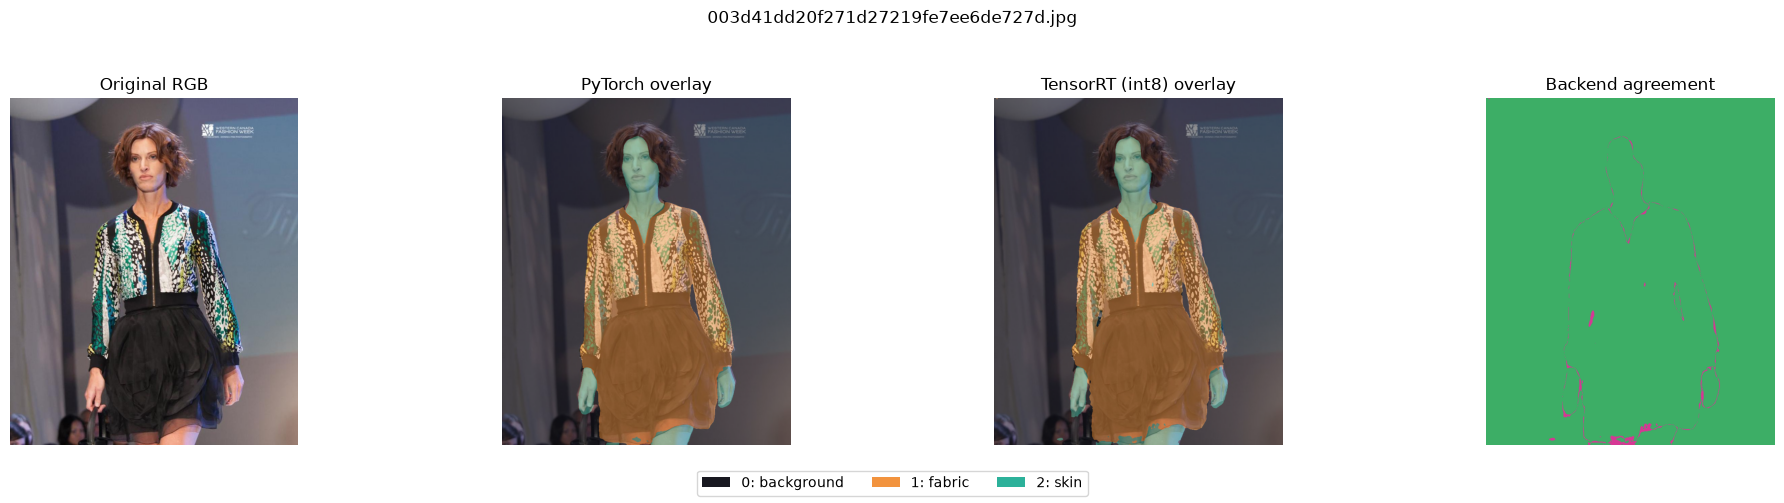

In [6]:
if trt_mask is None:
    panels = [source_rgb, colorize(torch_mask), overlay(source_rgb, torch_mask)]
    titles = ['Original RGB', 'PyTorch predicted mask', 'PyTorch overlay']
else:
    agreement = np.zeros_like(source_rgb)
    agreement[torch_mask == trt_mask] = (61, 174, 102)
    agreement[torch_mask != trt_mask] = (214, 55, 148)
    panels = [
        source_rgb,
        overlay(source_rgb, torch_mask),
        overlay(source_rgb, trt_mask),
        agreement,
    ]
    titles = [
        'Original RGB',
        'PyTorch overlay',
        f'TensorRT ({TRT_PRECISION}) overlay',
        'Backend agreement',
    ]

figure, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
for axis, panel, title in zip(np.atleast_1d(axes), panels, titles):
    axis.imshow(panel)
    axis.set_title(title)
    axis.axis('off')
legend = [Patch(facecolor=CLASS_COLORS[i] / 255.0, label=f'{i}: {name}') for i, name in enumerate(CLASS_NAMES)]
figure.legend(handles=legend, loc='lower center', ncol=len(CLASS_NAMES), frameon=True)
figure.suptitle(IMAGE_PATH.name)
figure.tight_layout(rect=(0, 0.08, 1, 0.94))
plt.show()

## Checks and optional benchmark

The checks below confirm valid class IDs and full-resolution output. If TensorRT ran, they also report class coverage and agreement. The optional benchmark uses synchronized GPU timing after warm-up; leave it disabled for a quick visual check.

In [7]:
assert torch_mask.shape == source_rgb.shape[:2]
assert set(np.unique(torch_mask)).issubset(set(range(NUM_CLASSES)))
coverage = {CLASS_NAMES[i]: float((torch_mask == i).mean()) for i in range(NUM_CLASSES)}
print('PyTorch pixel coverage:', coverage)

if trt_mask is not None:
    assert trt_mask.shape == source_rgb.shape[:2]
    assert set(np.unique(trt_mask)).issubset(set(range(NUM_CLASSES)))
    print('TensorRT pixel coverage:', {CLASS_NAMES[i]: float((trt_mask == i).mean()) for i in range(NUM_CLASSES)})
    print(f"Pixel agreement: {comparison['pixel_agreement']:.2%}")

if RUN_LATENCY_BENCHMARK:
    if trt_mask is None:
        print('Latency benchmark skipped because TensorRT did not run.')
    else:
        def benchmark(callable_, warmup=5, iterations=20):
            for _ in range(warmup):
                callable_()
            torch.cuda.synchronize(DEVICE)
            started = time.perf_counter()
            for _ in range(iterations):
                callable_()
            torch.cuda.synchronize(DEVICE)
            return (time.perf_counter() - started) * 1e3 / iterations

        eager_ms = benchmark(lambda: model(input_tensor))
        trt_ms = benchmark(lambda: decoder_runner(encoder_runner(input_tensor)))
        print(f'Eager PyTorch: {eager_ms:.2f} ms/image | TensorRT: {trt_ms:.2f} ms/image | speedup: {eager_ms / trt_ms:.2f}x')

PyTorch pixel coverage: {'background': 0.6702565654342723, 'fabric': 0.28459461194248825, 'skin': 0.04514882262323944}
TensorRT pixel coverage: {'background': 0.6709156305017606, 'fabric': 0.28120759059565725, 'skin': 0.04787677890258216}
Pixel agreement: 99.13%


## Next steps

- Select another checkpoint/engine pair with `MODEL_SIZE` and `TRT_PRECISION`.
- Set `IMAGE_PATH` to evaluate an external RGB image.
- Use `RUN_LATENCY_BENCHMARK = True` only on a compatible CUDA host.
- For a new checkpoint, run `scripts/export_trt.py` first, then add or update its manifest entry before using this notebook.